In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [86]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

# Automatically identify the two uploaded CSV files
apps_file = next(
    name for name in uploaded
    if "user_reviews" not in name.lower()
    and name.lower().endswith(".csv")
)

reviews_file = next(
    name for name in uploaded
    if "user_reviews" in name.lower()
    and name.lower().endswith(".csv")
)

apps = pd.read_csv(io.BytesIO(uploaded[apps_file]))
reviews = pd.read_csv(io.BytesIO(uploaded[reviews_file]))

print("Apps Dataset:", apps.shape)
print("Reviews Dataset:", reviews.shape)
print("Apps file:", apps_file)
print("Reviews file:", reviews_file)

Saving googleplaystore.csv to googleplaystore (5).csv
Saving googleplaystore_user_reviews.csv to googleplaystore_user_reviews (5).csv
Apps Dataset: (10841, 13)
Reviews Dataset: (64295, 5)
Apps file: googleplaystore (5).csv
Reviews file: googleplaystore_user_reviews (5).csv


In [87]:
print("APPS DATASET")
display(apps.head())

print("USER REVIEWS DATASET")
display(reviews.head())

APPS DATASET


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


USER REVIEWS DATASET


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [88]:
print("APPS DATASET INFO")
apps.info()

print("\nUSER REVIEWS DATASET INFO")
reviews.info()

APPS DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB

USER REVIEWS DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Colum

In [89]:
print("Missing values in Apps:")
display(apps.isnull().sum())

print("\nMissing values in User Reviews:")
display(reviews.isnull().sum())

Missing values in Apps:


,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0



Missing values in User Reviews:


,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


In [90]:
print("Duplicate app rows:", apps.duplicated().sum())
print("Duplicate review rows:", reviews.duplicated().sum())

Duplicate app rows: 483
Duplicate review rows: 33616


In [92]:
print("Missing Values in Apps:")
print(apps.isnull().sum())

print("\nMissing Values in User Reviews:")
print(reviews.isnull().sum())


Missing Values in Apps:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Missing Values in User Reviews:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [93]:
apps_clean = apps.copy()

# Remove duplicate rows
apps_clean = apps_clean.drop_duplicates()

# Remove invalid rating values
apps_clean["Rating"] = pd.to_numeric(
    apps_clean["Rating"], errors="coerce"
)

apps_clean.loc[
    (apps_clean["Rating"] < 1) | (apps_clean["Rating"] > 5),
    "Rating"
] = np.nan

# Clean Reviews
apps_clean["Reviews"] = pd.to_numeric(
    apps_clean["Reviews"], errors="coerce"
)

# Clean Installs
apps_clean["Installs"] = (
    apps_clean["Installs"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)

apps_clean["Installs"] = pd.to_numeric(
    apps_clean["Installs"], errors="coerce"
)

# Clean Price
apps_clean["Price"] = (
    apps_clean["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

apps_clean["Price"] = pd.to_numeric(
    apps_clean["Price"], errors="coerce"
)

# Convert Last Updated to datetime
apps_clean["Last Updated"] = pd.to_datetime(
    apps_clean["Last Updated"], errors="coerce"
)

print("Original shape:", apps.shape)
print("Cleaned shape:", apps_clean.shape)
display(apps_clean.head())

Original shape: (10841, 13)
Cleaned shape: (10358, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [94]:
# Remove the malformed app record
apps_clean = apps_clean[
    (apps_clean["Category"].astype(str) != "1.9") &
    (apps_clean["Type"].astype(str) != "0")
].copy()

print("Shape after removing invalid records:", apps_clean.shape)

Shape after removing invalid records: (10357, 13)


In [95]:
# Remove rows with invalid app categories
apps_clean = apps_clean[
    apps_clean["Category"].astype(str).str.fullmatch(r"[A-Z_]+", na=False)
].copy()

In [96]:
reviews_clean = reviews.copy()

# Remove duplicate review rows
reviews_clean = reviews_clean.drop_duplicates()

# Remove rows with missing review text
reviews_clean = reviews_clean.dropna(
    subset=["Translated_Review"]
)

# Remove blank review text
reviews_clean = reviews_clean[
    reviews_clean["Translated_Review"].astype(str).str.strip() != ""
]

print("Original reviews shape:", reviews.shape)
print("Cleaned reviews shape:", reviews_clean.shape)

print("\nRemaining missing values:")
display(reviews_clean.isnull().sum())

Original reviews shape: (64295, 5)
Cleaned reviews shape: (29692, 5)

Remaining missing values:


,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


In [97]:

print("Cleaned Apps Dataset Shape:", apps_clean.shape)

print("\nMissing Values:")
print(apps_clean.isnull().sum())

print("\nData Types:")
print(apps_clean.dtypes)

print("\nDuplicate Rows:", apps_clean.duplicated().sum())

print("\nUnique App Categories:", apps_clean["Category"].nunique())

print("\nApp Types:")
print(apps_clean["Type"].value_counts(dropna=False))

Cleaned Apps Dataset Shape: (10357, 13)

Missing Values:
App                  0
Category             0
Rating            1465
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

Data Types:
App                       object
Category                  object
Rating                   float64
Reviews                  float64
Size                      object
Installs                 float64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
dtype: object

Duplicate Rows: 0

Unique App Categories: 33

App Types:
Type
Free    9591
Paid     765
NaN        1
Name: count, dtype: int64


Top 10 Categories by Number of Apps:


,Category,count
0,FAMILY,1943
1,GAME,1121
2,TOOLS,843
3,BUSINESS,427
4,MEDICAL,408
5,PRODUCTIVITY,407
6,PERSONALIZATION,388
7,LIFESTYLE,373
8,COMMUNICATION,366
9,FINANCE,360


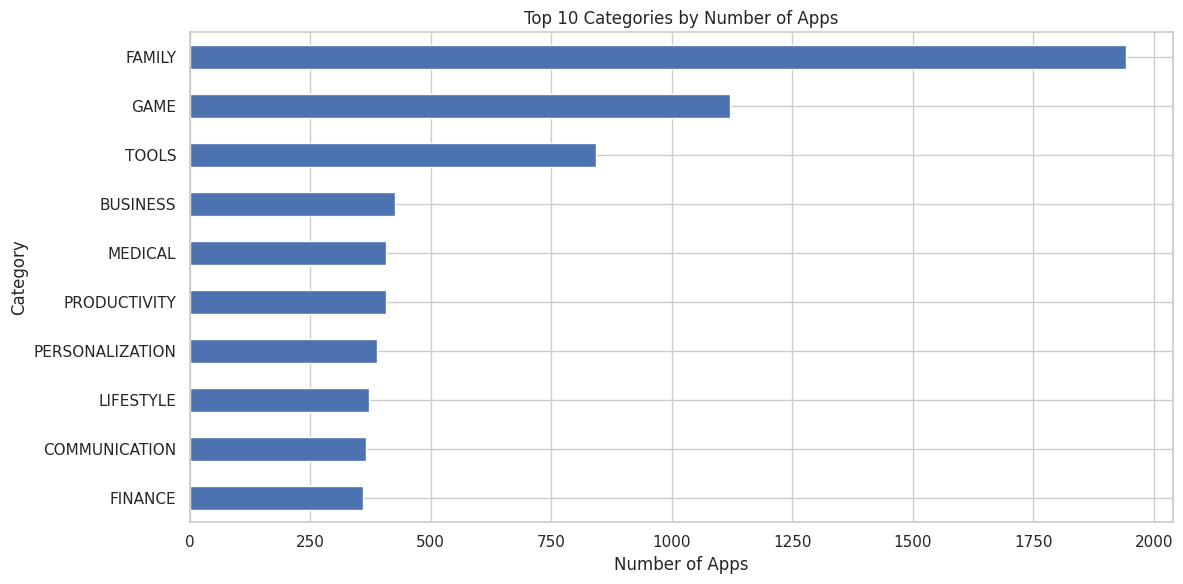

In [98]:

category_counts = (
    apps_clean["Category"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Top 10 Categories by Number of Apps:")
display(category_counts.head(10).reset_index())

plt.figure(figsize=(12, 6))
category_counts.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Categories by Number of Apps")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

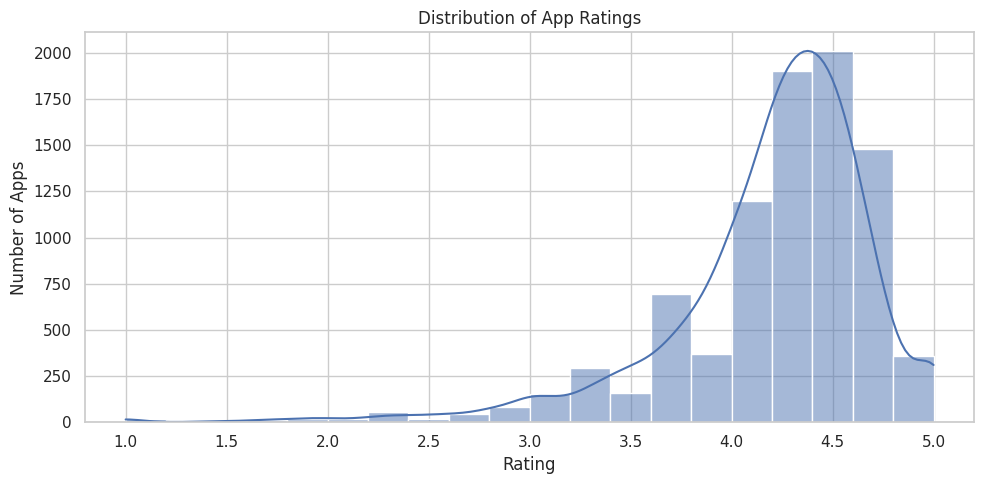

In [99]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=apps_clean,
    x="Rating",
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

Top 10 Categories by Average Rating:


,Category,Rating
0,EVENTS,4.44
1,EDUCATION,4.38
2,ART_AND_DESIGN,4.36
3,BOOKS_AND_REFERENCE,4.35
4,PERSONALIZATION,4.33
5,PARENTING,4.30
6,GAME,4.28
7,BEAUTY,4.28
8,HEALTH_AND_FITNESS,4.26
9,SOCIAL,4.25


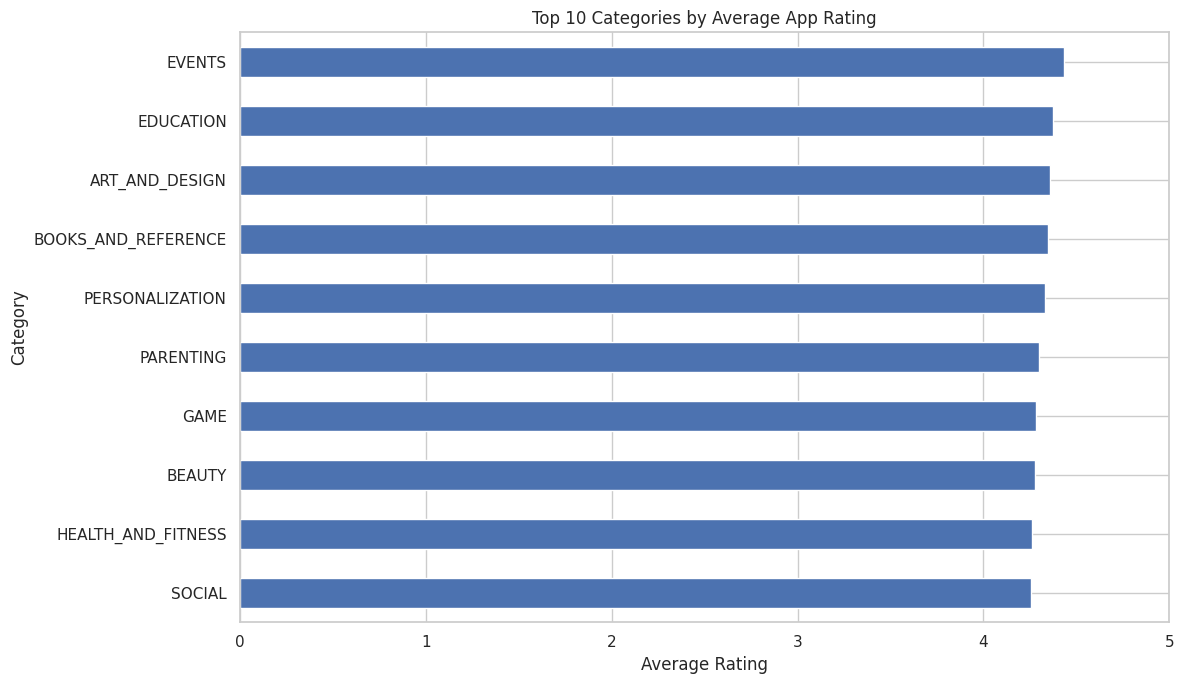

In [100]:
avg_rating = (
    apps_clean.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 Categories by Average Rating:")
display(avg_rating.head(10).round(2).reset_index())

plt.figure(figsize=(12, 7))

avg_rating.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Categories by Average App Rating")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

In [101]:
print("Bottom 10 Categories by Average Rating:")
display(avg_rating.tail(10).round(2).reset_index())

Bottom 10 Categories by Average Rating:


,Category,Rating
0,ENTERTAINMENT,4.14
1,NEWS_AND_MAGAZINES,4.13
2,FINANCE,4.13
3,BUSINESS,4.10
4,LIFESTYLE,4.10
5,TRAVEL_AND_LOCAL,4.09
6,VIDEO_PLAYERS,4.06
7,MAPS_AND_NAVIGATION,4.05
8,TOOLS,4.05
9,DATING,3.97


In [102]:
size_data = apps_clean.copy()

size_data["Size_MB"] = (
    size_data["Size"]
    .astype(str)
    .str.strip()
    .replace("Varies with device", np.nan)
    .replace("nan", np.nan)
)

size_data.loc[
    size_data["Size_MB"].str.endswith("k", na=False), "Size_MB"
] = (
    size_data.loc[
        size_data["Size_MB"].str.endswith("k", na=False), "Size_MB"
    ].str[:-1].astype(float) / 1024
).astype(str)

size_data["Size_MB"] = (
    size_data["Size_MB"]
    .str.replace("M", "", regex=False)
)

size_data["Size_MB"] = pd.to_numeric(
    size_data["Size_MB"], errors="coerce"
)

print("Missing app sizes:", size_data["Size_MB"].isnull().sum())

Missing app sizes: 1526


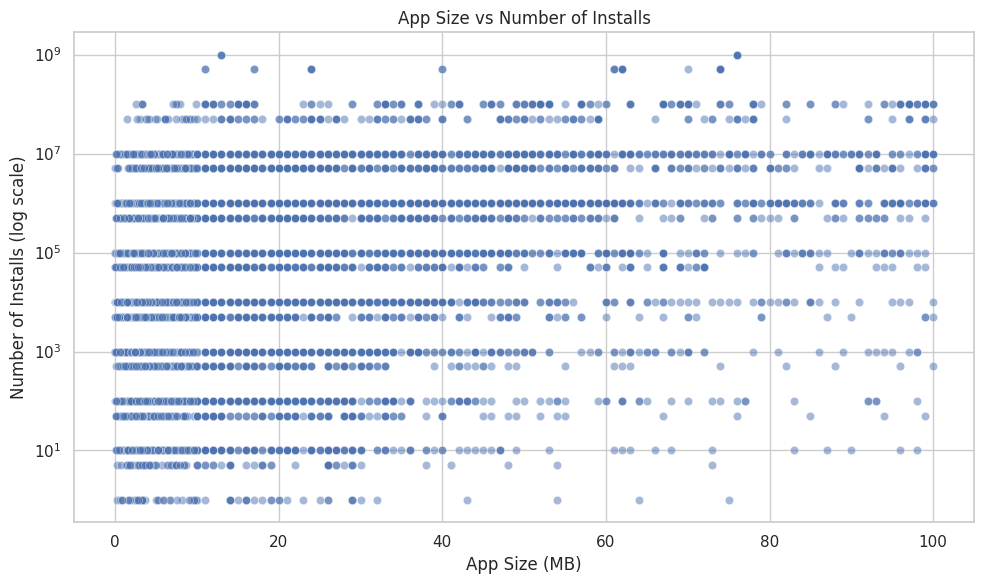

In [103]:
size_installs = size_data.dropna(
    subset=["Size_MB", "Installs"]
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_installs,
    x="Size_MB",
    y="Installs",
    alpha=0.5
)

plt.yscale("log")
plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs (log scale)")
plt.tight_layout()
plt.show()

In [104]:
correlation = size_installs[
    ["Size_MB", "Installs"]
].corr().iloc[0, 1]

print("Correlation between App Size and Installs:", round(correlation, 3))

Correlation between App Size and Installs: 0.169


Type
Free    9591
Paid     765
Name: count, dtype: int64


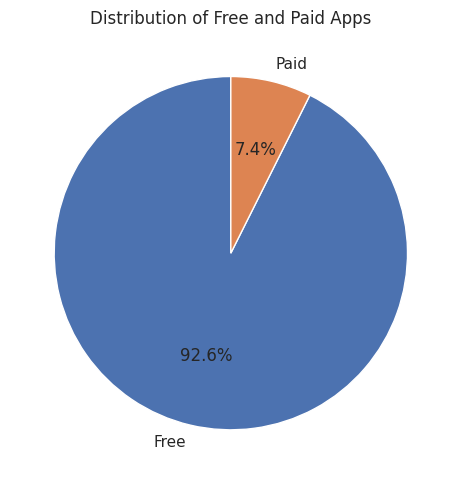

In [105]:
type_counts = apps_clean["Type"].value_counts()

print(type_counts)

plt.figure(figsize=(7, 5))
type_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Free and Paid Apps")
plt.ylabel("")
plt.tight_layout()
plt.show()

Number of paid apps: 765
count    765.000000
mean      13.955556
std       58.406966
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64


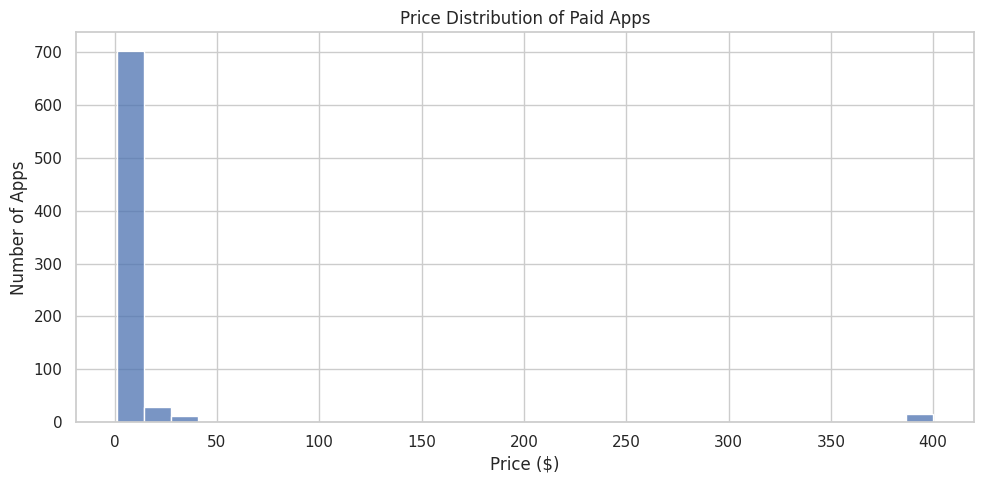

In [106]:
paid_apps = apps_clean[
    (apps_clean["Type"] == "Paid") &
    (apps_clean["Price"] > 0)
].copy()

print("Number of paid apps:", len(paid_apps))
print(paid_apps["Price"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(data=paid_apps, x="Price", bins=30)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

In [107]:

paid_apps = paid_apps.dropna(subset=["Installs"])

Top 10 Categories by Estimated Revenue:


,Category,Estimated_Revenue
0,FAMILY,1.857803e+08
1,LIFESTYLE,5.758394e+07
2,GAME,4.098764e+07
3,FINANCE,2.572668e+07
4,PHOTOGRAPHY,8.942768e+06
5,MEDICAL,8.456536e+06
6,PERSONALIZATION,7.786948e+06
7,TOOLS,5.464821e+06
8,SPORTS,4.706212e+06
9,PRODUCTIVITY,4.313375e+06


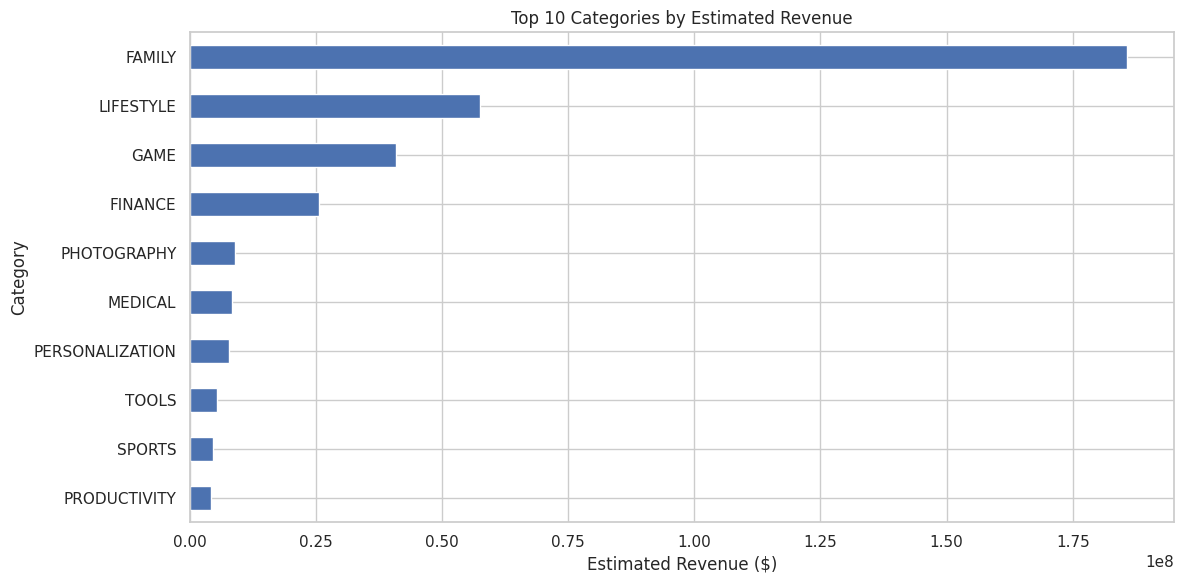

In [108]:
paid_apps = paid_apps.copy()

paid_apps["Estimated_Revenue"] = (
    paid_apps["Price"] * paid_apps["Installs"]
)

revenue_by_category = (
    paid_apps.groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 Categories by Estimated Revenue:")
display(
    revenue_by_category.head(10)
    .round(2)
    .reset_index()
)

plt.figure(figsize=(12, 6))

revenue_by_category.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Categories by Estimated Revenue")
plt.xlabel("Estimated Revenue ($)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [109]:
!pip -q install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [110]:
def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

reviews_clean["Calculated_Sentiment"] = (
    reviews_clean["Translated_Review"].apply(get_sentiment)
)

print("Sentiment Analysis Results:")
display(
    reviews_clean["Calculated_Sentiment"]
    .value_counts()
    .rename_axis("Sentiment")
    .reset_index(name="Number of Reviews")
)

Sentiment Analysis Results:


,Sentiment,Number of Reviews
0,Positive,20197
1,Negative,5866
2,Neutral,3629


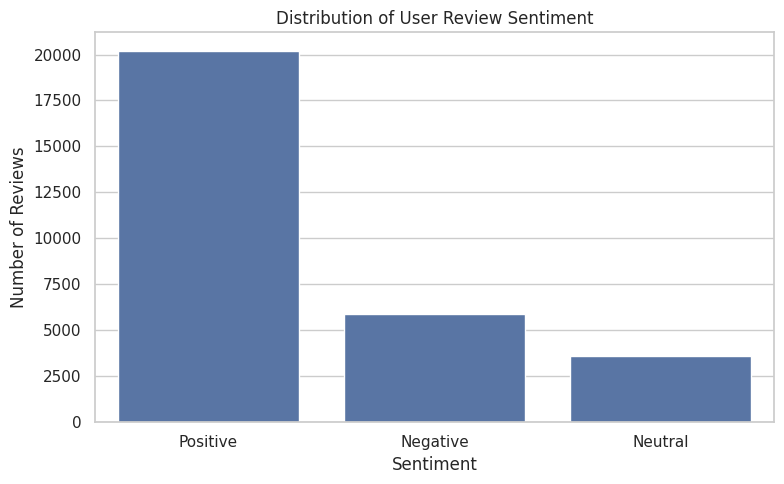

In [111]:
sentiment_counts = reviews_clean["Calculated_Sentiment"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Distribution of User Review Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [112]:
app_categories = (
    apps_clean[["App", "Category"]]
    .dropna()
    .drop_duplicates()
    .drop_duplicates(subset="App", keep="first")
)

reviews_with_category = reviews_clean.merge(
    app_categories,
    on="App",
    how="inner"
)

print("Reviews matched to app categories:",
      len(reviews_with_category))

print("Unmatched review rows:",
      len(reviews_clean) - len(reviews_with_category))

Reviews matched to app categories: 28250
Unmatched review rows: 1442


In [113]:
sentiment_by_category = pd.crosstab(
    reviews_with_category["Category"],
    reviews_with_category["Calculated_Sentiment"]
)

display(sentiment_by_category.head())

Calculated_Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,47,42,265
AUTO_AND_VEHICLES,14,36,233
BEAUTY,64,62,191
BOOKS_AND_REFERENCE,99,71,447
BUSINESS,111,130,416


In [114]:
sentiment_percent = sentiment_by_category.div(
    sentiment_by_category.sum(axis=1), axis=0
) * 100

if "Positive" in sentiment_percent.columns:
    print("Top 10 Categories by Positive Sentiment (%)")
    display(
        sentiment_percent["Positive"]
        .sort_values(ascending=False)
        .head(10)
        .round(2)
        .reset_index(name="Positive Sentiment (%)")
    )

if "Negative" in sentiment_percent.columns:
    print("Top 10 Categories by Negative Sentiment (%)")
    display(
        sentiment_percent["Negative"]
        .sort_values(ascending=False)
        .head(10)
        .round(2)
        .reset_index(name="Negative Sentiment (%)")
    )

Top 10 Categories by Positive Sentiment (%)


,Category,Positive Sentiment (%)
0,COMICS,86.67
1,AUTO_AND_VEHICLES,82.33
2,EVENTS,80.13
3,EDUCATION,78.73
4,HEALTH_AND_FITNESS,78.47
5,ART_AND_DESIGN,74.86
6,FOOD_AND_DRINK,73.76
7,PARENTING,73.44
8,GAME,73.00
9,FAMILY,72.86


Top 10 Categories by Negative Sentiment (%)


,Category,Negative Sentiment (%)
0,VIDEO_PLAYERS,31.90
1,SOCIAL,31.47
2,ENTERTAINMENT,26.84
3,NEWS_AND_MAGAZINES,25.24
4,COMMUNICATION,25.15
5,FINANCE,24.18
6,DATING,22.26
7,SPORTS,22.04
8,TRAVEL_AND_LOCAL,21.79
9,SHOPPING,21.42


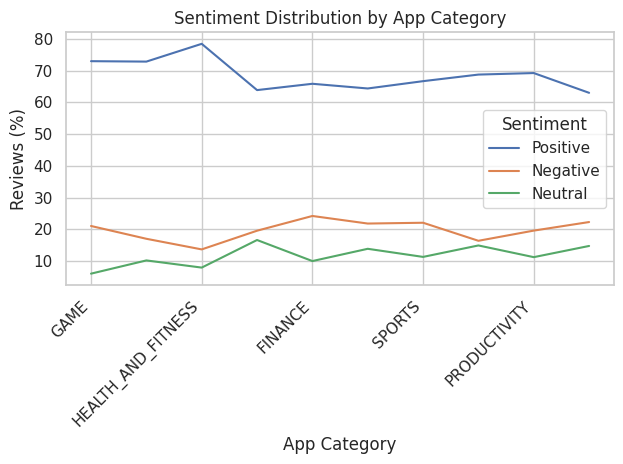

In [115]:
# Select categories with the most matched reviews
top_categories = (
    reviews_with_category["Category"]
    .value_counts()
    .head(10)
    .index
)

plot_data = sentiment_percent.loc[
    sentiment_percent.index.isin(top_categories)
].copy()

plot_data = plot_data.reindex(top_categories)


sentiment_order = ["Positive", "Negative", "Neutral"]

plot_data = plot_data.reindex(
    columns=sentiment_order, fill_value=0
)

plot_data.plot()

plt.title("Sentiment Distribution by App Category")
plt.xlabel("App Category")
plt.ylabel("Reviews (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [116]:
!pip -q install plotly

import plotly.express as px

plotly_data = (
    apps_clean.groupby("Category")
    .agg(
        Number_of_Apps=("App", "count"),
        Average_Rating=("Rating", "mean"),
        Total_Installs=("Installs", "sum")
    )
    .reset_index()
)

fig = px.scatter(
    plotly_data,
    x="Number_of_Apps",
    y="Average_Rating",
    size="Total_Installs",
    hover_name="Category",
    title="App Categories: Competition, Ratings and Installs",
    labels={
        "Number_of_Apps": "Number of Apps",
        "Average_Rating": "Average Rating",
        "Total_Installs": "Total Installs"
    }
)

fig.show()

In [117]:

# 1. Most common app category
print("1. MOST COMMON APP CATEGORY")
print(category_counts.head(1))

# 2. Highest average rating category
print("\n2. HIGHEST AVERAGE RATING CATEGORY")
print(avg_rating.dropna().head(1).round(2))

# 3. Category with highest estimated paid-app revenue
print("\n3. CATEGORY WITH HIGHEST ESTIMATED PAID-APP REVENUE")
print(revenue_by_category.head(1).round(2))

# 4. Sentiment summary (safe version)
print("\n4. SENTIMENT SUMMARY")

sentiment_columns = [
    col for col in ["Positive", "Negative", "Neutral"]
    if col in sentiment_percent.columns
]

if sentiment_columns:
    display(
        sentiment_percent[sentiment_columns]
        .sort_values(
            by="Positive",
            ascending=False
        ) if "Positive" in sentiment_columns
        else sentiment_percent[sentiment_columns]
    )
else:
    print("No sentiment columns found. Check Cell 25.")

1. MOST COMMON APP CATEGORY
Category
FAMILY    1943
Name: count, dtype: int64

2. HIGHEST AVERAGE RATING CATEGORY
Category
EVENTS    4.44
Name: Rating, dtype: float64

3. CATEGORY WITH HIGHEST ESTIMATED PAID-APP REVENUE
Category
FAMILY    1.857803e+08
Name: Estimated_Revenue, dtype: float64

4. SENTIMENT SUMMARY


Calculated_Sentiment,Positive,Negative,Neutral
Category,,,
COMICS,86.666667,2.222222,11.111111
AUTO_AND_VEHICLES,82.332155,4.946996,12.720848
EVENTS,80.128205,12.179487,7.692308
EDUCATION,78.726708,10.403727,10.869565
HEALTH_AND_FITNESS,78.470080,13.633560,7.896360
ART_AND_DESIGN,74.858757,13.276836,11.864407
FOOD_AND_DRINK,73.756432,15.265866,10.977702
PARENTING,73.437500,10.546875,16.015625
GAME,72.997238,21.017495,5.985267


In [118]:
apps_clean.to_csv("googleplaystore_cleaned.csv", index=False)

reviews_clean.to_csv("googleplaystore_reviews_cleaned.csv", index=False)

reviews_with_category.to_csv(
    "googleplaystore_reviews_with_sentiment.csv",
    index=False
)

print("Cleaned datasets exported successfully!")

Cleaned datasets exported successfully!


In [119]:
from google.colab import files

files.download("googleplaystore_cleaned.csv")
files.download("googleplaystore_reviews_cleaned.csv")
files.download("googleplaystore_reviews_with_sentiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>